# Lesson 3: Advanced Usage (FlashBackGraph)

In Lessons 1 and 2 you built `FlashBackGraph`s and used their
closed-form analytics. This lesson covers the workflows that combine
multiple graphs, update them with new data, mine them for interesting
sequences, build them efficiently from huge inputs, and turn them
into features for ML.

By the end you'll be able to:

1. Combine FlashBack graphs with the set-algebra operators
   (`|`, `&`, `-`) and `weighted_merge`
2. Personalize a population graph with `posterior(...)` and tune the
   `kappa` prior-strength parameter
3. Use `without(...)` to perform fast "leave-one-out" subtractions
4. Mine the most-probable sequences with `top_k_sequences()`
5. Build a graph from a sequence stream that won't fit in RAM, with
   `FlashBackStream`'s `add_sequences` / `snapshot` / `finalize` API
6. Build feature vectors for ML pipelines when the LZGraph-style
   `feature_aligned` projection isn't available

> **What `FlashBackGraph` does *not* support.** Three things in the
> LZGraph advanced toolkit have no direct FB equivalent:
>
> - **V/J gene data.** FB does not carry `v_marginals`,
>   `j_marginals`, `vj_distribution`, or gene-conditioned simulation.
>   If you need gene-aware modeling, use `LZGraph` for that part of
>   the pipeline.
> - **`feature_aligned(query)`.** Not implemented for FB. We show a
>   work-around using `pgen()` and `flashback_fbas()` as features.
> - **`feature_mass_profile()`.** Method exists on the FB class but
>   raises an error on the actual graph (a known limitation).
>
> Everything else maps cleanly across the two graph families.


In [1]:
from LZGraphs import FlashBackGraph, FlashBackStream
import numpy as np
import csv
import matplotlib.pyplot as plt


## Setup: load the data and build the reference graph

Same 5,000 amino-acid CDR3 repertoire as in Lessons 1 and 2. We also
load the V gene calls so the final section can split sequences by V
into two classes for the classifier demo.


In [2]:
sequences, v_genes = [], []
with open('../data/ExampleData3.csv') as f:
    for row in csv.DictReader(f):
        sequences.append(row['cdr3_amino_acid'])
        v_genes.append(row['V'])

graph = FlashBackGraph(sequences)
print(graph)


FlashBackGraph(nodes=2826, edges=11899)


## 1. Set algebra: union, intersection, difference

The three set-algebra operators behave identically to their LZGraph
counterparts:

| Operator | Method | Edge weights |
|---|---|---|
| `g1 \| g2` | `union(g2)` | sum of counts from both graphs |
| `g1 & g2` | `intersection(g2)` | min of counts (only edges in *both*) |
| `g1 - g2` | `difference(g2)` | g1 counts minus g2 counts (clipped to non-negative) |

All three return a fully usable `FlashBackGraph`.


In [3]:
# Split repertoire into two equal halves
g_a = FlashBackGraph(sequences[:2500])
g_b = FlashBackGraph(sequences[2500:])

g_union  = g_a | g_b
g_inter  = g_a & g_b
g_diff_a = g_a - g_b
g_diff_b = g_b - g_a

print(f'g_a:      {g_a}')
print(f'g_b:      {g_b}')
print(f'g_a | g_b:{g_union}')
print(f'g_a & g_b:{g_inter}')
print(f'g_a - g_b:{g_diff_a}')
print(f'g_b - g_a:{g_diff_b}')


g_a:      FlashBackGraph(nodes=2070, edges=6735)
g_b:      FlashBackGraph(nodes=2085, edges=6699)
g_a | g_b:FlashBackGraph(nodes=2826, edges=11899)
g_a & g_b:FlashBackGraph(nodes=647, edges=1535)
g_a - g_b:FlashBackGraph(nodes=2054, edges=5622)
g_b - g_a:FlashBackGraph(nodes=2070, edges=5596)


In [4]:
# Edge-level identity check: |A ∪ B| = |A| + |B| - |A ∩ B|
expected = g_a.n_edges + g_b.n_edges - g_inter.n_edges
print(f'expected union edges: {expected:,d}')
print(f'actual   union edges: {g_union.n_edges:,d}')
print(f'match: {expected == g_union.n_edges}')

# And the union of the two halves should equal the full repertoire graph
print()
print(f'union nodes: {g_union.n_nodes:,d}   full graph: {graph.n_nodes:,d}   '
      f'match: {g_union.n_nodes == graph.n_nodes}')
print(f'union edges: {g_union.n_edges:,d}   full graph: {graph.n_edges:,d}   '
      f'match: {g_union.n_edges == graph.n_edges}')


expected union edges: 11,899
actual   union edges: 11,899
match: True

union nodes: 2,826   full graph: 2,826   match: True
union edges: 11,899   full graph: 11,899   match: True


## 2. Weighted merge: proportional blending

`weighted_merge(other, alpha, beta)` is the soft-blend version of
union: each edge weight becomes `alpha * w_self + beta * w_other`.
Use it when you want to combine repertoires with different per-sample
weights without re-collecting raw sequences.


In [5]:
g_merged = g_a.weighted_merge(g_b, alpha=0.7, beta=0.3)
print(f'0.7 * g_a + 0.3 * g_b: {g_merged}')

# Show how a sequence's pgen shifts under the blend
seq = sequences[0]
print(f'log P({seq!r}):')
print(f'  in g_a:    {g_a.pgen(seq):.4f}')
print(f'  in g_b:    {g_b.pgen(seq):.4f}')
print(f'  in merged: {g_merged.pgen(seq):.4f}')


0.7 * g_a + 0.3 * g_b: FlashBackGraph(nodes=2100, edges=7085)
log P('CASSGLAGSRSYNEQFF'):
  in g_a:    -15.5672
  in g_b:    -690.7755
  in merged: -15.2640


## 3. Bayesian posterior personalization

Identical interface to the LZGraph version: blend a prior graph with
patient-specific evidence by a Dirichlet pseudocount `kappa`.

$$ w_{\text{post}}(u \to v) = \frac{\kappa\, w_{\text{prior}}(u \to v) + c_{\text{ind}}(u \to v)}{\kappa + n_{\text{ind}}(u)} $$

The posterior graph keeps the same node structure as the prior;
patient sequences whose FlashBack walks would require novel nodes
get added at low weight rather than dropped (more on this below).


In [6]:
prior = FlashBackGraph(sequences[:1000])
new_data = sequences[1000:1500]
print(f'Prior:    {prior}')
print(f'New data: {len(new_data)} sequences')

# Pick an in-prior sequence and watch its log-P shift with kappa
test_seq = sequences[5]
print()
print(f'log P({test_seq!r}) under varying kappa:')
print(f'  prior:               {prior.pgen(test_seq):>8.4f}')
for kappa in [0.1, 1.0, 10.0, 100.0]:
    post = prior.posterior(new_data, kappa=kappa)
    print(f'  posterior (kappa={kappa:>5.1f}):  {post.pgen(test_seq):>8.4f}')


Prior:    FlashBackGraph(nodes=1300, edges=3089)
New data: 500 sequences

log P('CASSPQDRPNYGYTF') under varying kappa:
  prior:               -10.2101
  posterior (kappa=  0.1):  -10.1965
  posterior (kappa=  1.0):  -10.2556
  posterior (kappa= 10.0):  -10.3909
  posterior (kappa=100.0):  -10.2234


Read this the same way as in the LZGraph track: low `kappa` means
"trust the new data", high `kappa` means "stick close to the prior".
Pick a value that reflects how confident you are in the
patient-specific batch relative to the population baseline.


## 4. `without()`: removing sequences from a graph

A FlashBack-specific tool. `without(sequences)` returns a new graph
with each provided sequence's walk subtracted from the edge counts.
Counts are clamped at zero, edges that reach zero are pruned, and
remaining edge weights are renormalized at the source node.

The canonical use case: **leave-donor-out foundation construction**.
You have a population graph built from many donors and want to
evaluate per-donor effects by removing each donor in turn. Without
`without()`, you'd rebuild the population graph from scratch for each
left-out donor (slow). With it, the operation is seconds.


In [7]:
# Demonstration: remove the contributions of the first 100 sequences
g_full   = FlashBackGraph(sequences[:1000])
g_minus  = g_full.without(sequences[:100])
g_direct = FlashBackGraph(sequences[100:1000])

print(f'Full:                              {g_full}')
print(f'Full.without(first 100):           {g_minus}')
print(f'Direct rebuild from seq[100:1000]: {g_direct}')

# The two paths should give the same edge count (modulo pruning of edges
# that fall to zero only when subtracted, not when never built).
print()
print(f'edges match: {g_minus.n_edges == g_direct.n_edges}')
print(f'nodes match: {g_minus.n_nodes == g_direct.n_nodes}')


Full:                              FlashBackGraph(nodes=1300, edges=3089)
Full.without(first 100):           FlashBackGraph(nodes=1300, edges=2802)
Direct rebuild from seq[100:1000]: FlashBackGraph(nodes=1236, edges=2802)

edges match: True
nodes match: False


The fact that `without` reproduces a from-scratch rebuild (within
edge-pruning tolerances) means you can use it as a fast cache: build
the foundation once, subtract the test donor's contribution to get
the leave-one-out reference.


## 5. Top-k mining: find the most probable walks

`top_k_sequences(k)` returns the `k` highest-probability walks
through the graph. Because the FlashBack tokenization is unique per
sequence and the graph is Markovian, the top walks are *exact* and
computed deterministically.

This is useful for repertoire characterization (what does the model
consider the "most typical" sequences?) and for spot-checking your
graph (are the top sequences plausible?). Pass `most_probable=False`
to get the least-probable walks instead.


In [8]:
top = graph.top_k_sequences(10)
for s, lp in zip(top.sequences, top.log_probs):
    print(f'  log P = {lp:>8.4f}   {s}')


  log P =  -7.7351   CASSQDWGGIGYTF
  log P =  -8.2495   CASSQGGHPQYF
  log P =  -8.5172   CASSSGTGDSAFF
  log P =  -8.5172   CARDTEAFF
  log P =  -8.5172   CSVGQTLSAFF
  log P =  -8.5178   CASSSSSGEQYF
  log P =  -8.5196   CASSAGTGGGYTF
  log P =  -8.5196   CASSQSQGGGYTF
  log P =  -8.5196   CASSVDDRGSYTF
  log P =  -8.5196   CASSDRVGGYTF


In [9]:
# Tail-end mining: the least-probable walks
bottom = graph.top_k_sequences(10, most_probable=False)
print('Least-probable walks (still valid under the graph):')
for s, lp in zip(bottom.sequences, bottom.log_probs):
    print(f'  log P = {lp:>8.4f}   {s}')


Least-probable walks (still valid under the graph):
  log P = -38.3875   CASSPGRTGSGSGNGKYFF
  log P = -38.3875   CASSPGRTGQGSGNGKYFF
  log P = -38.3875   CASSPGRTGLGSGNGKYFF
  log P = -38.3875   CASSPGRTGIGSGNGKYFF
  log P = -38.3875   CASSPGRTGTSGSGNGKYFF
  log P = -38.3875   CASSPGRTGKGSGNGKYFF
  log P = -38.3875   CASSPGRTGVRLGSGNGKYFF
  log P = -38.3875   CASSPGRTGAGSGNGKYFF
  log P = -38.3238   CASSLDGTGGVIGTNGKYFF
  log P = -38.3238   CASSLDGTGGLIGTNGKYFF


## 6. Streaming builds with `FlashBackStream`

For repertoires that don't fit in RAM, `FlashBackStream` lets you
push sequences in batches, peek or snapshot the running state, and
finalize when you're done. The accumulator memory grows with the
number of *distinct* nodes/edges, not with the total number of input
sequences, so very large inputs work fine.

`FlashBackStream` is a context manager. The three operations:

| Method | Behavior |
|---|---|
| `add_sequences(seqs, abundances=None)` | Push a batch into the accumulator |
| `peek()` | Return `{n_nodes, n_edges}` without materializing a graph |
| `snapshot()` | Return a finalized `FlashBackGraph` for current state, without consuming the stream |
| `finalize()` | Consume the stream and return the final graph |
| `abort()` | Discard the partial accumulator |


In [10]:
# Demonstration: stream the same 5,000 sequences in batches of 1,000
# and take a snapshot after each batch so we can plot graph growth.
batch_size = 1000
sizes = []

with FlashBackStream() as stream:
    for start in range(0, len(sequences), batch_size):
        stream.add_sequences(sequences[start:start+batch_size])
        snap = stream.snapshot()
        sizes.append((start + batch_size, snap.n_nodes, snap.n_edges))
    final = stream.finalize()

print('After each batch (cumulative):')
print('n_seqs   n_nodes   n_edges')
for n, no, ne in sizes:
    print(f'  {n:>5,d}    {no:>5,d}    {ne:>5,d}')

print()
print(f'final: {final}')
print(f'matches direct build: {final.n_nodes == graph.n_nodes and final.n_edges == graph.n_edges}')


After each batch (cumulative):
n_seqs   n_nodes   n_edges
  1,000    1,300    3,089
  2,000    1,854    5,590
  3,000    2,261    7,830
  4,000    2,574    9,930
  5,000    2,826    11,899

final: FlashBackGraph(nodes=2826, edges=11899)
matches direct build: True


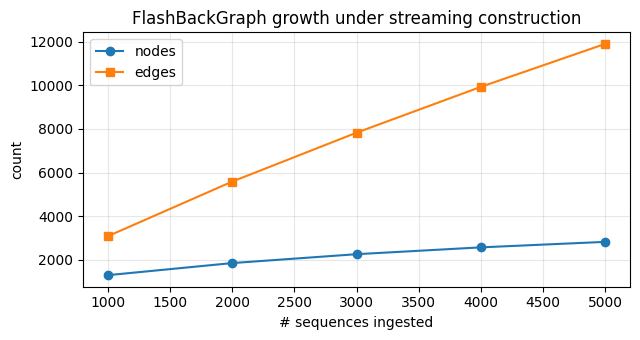

In [11]:
# Plot the growth curve
ns    = [n for n, _, _ in sizes]
nodes = [no for _, no, _ in sizes]
edges = [ne for _, _, ne in sizes]

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(ns, nodes, 'o-', label='nodes')
ax.plot(ns, edges, 's-', label='edges')
ax.set_xlabel('# sequences ingested')
ax.set_ylabel('count')
ax.set_title('FlashBackGraph growth under streaming construction')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


For *very* large inputs (millions of sequences from disk), use
`FlashBackGraph.from_file('huge.tsv')` instead, which wraps the same
streaming machinery and avoids constructing a Python list at all.
`FlashBackStream` is the right primitive when you need to interleave
ingestion with checkpointing or want to abort early.


## 7. Building ML features without `feature_aligned`

The LZGraph track uses `feature_aligned` to project a query graph
into a reference's node space, producing a fixed-size feature vector
that scikit-learn can consume. That API isn't implemented on FB. The
work-around is to score each test sequence under *each* reference
graph and use the scores themselves as features. Two reference
graphs gives you an 8-dimensional feature per sequence:

| Index | Feature |
|---|---|
| 0, 1 | `fbas` under reference 0 and 1 |
| 2, 3 | `log_pgen` under each reference |
| 4, 5 | `n_missing_tokens` under each reference |
| 6, 7 | `n_missing_edges` under each reference |

`flashback_fbas()` returns all of these at once, so this is a single
pass per reference graph per test sequence.


In [12]:
def fb_features(seq_list, ref0, ref1):
    """Compute an 8-dim FB-feature row for each test sequence."""
    rows = []
    for s in seq_list:
        f0 = ref0.flashback_fbas(s)
        f1 = ref1.flashback_fbas(s)
        rows.append([
            f0['fbas'],              f1['fbas'],
            f0['log_pgen'],          f1['log_pgen'],
            f0['n_missing_tokens'],  f1['n_missing_tokens'],
            f0['n_missing_edges'],   f1['n_missing_edges'],
        ])
    return np.array(rows, dtype=float)


## 8. End-to-end: V-gene classifier from FB features

Putting it all together: pick the two most-common V genes, build a
`FlashBackGraph` per V from the training half, and train a logistic
regression on the FB-derived features. On this dataset you should
see a modest but real signal above chance. The exact numbers will
depend on how well-separated the two V genes' CDR3 distributions are
in FlashBack-token space.


In [13]:
from collections import Counter

# Pick the two most common V genes
top2_v = [v for v, _ in Counter(v_genes).most_common(2)]
idx_0 = [i for i, v in enumerate(v_genes) if v == top2_v[0]]
idx_1 = [i for i, v in enumerate(v_genes) if v == top2_v[1]]
print(f'Two most common V genes: {top2_v}')
print(f'Class 0 ({top2_v[0]}): {len(idx_0)} sequences')
print(f'Class 1 ({top2_v[1]}): {len(idx_1)} sequences')

# 70/30 train/test split per class
s0 = int(0.7 * len(idx_0)); s1 = int(0.7 * len(idx_1))
train_0 = [sequences[i] for i in idx_0[:s0]]
train_1 = [sequences[i] for i in idx_1[:s1]]
test_0  = [sequences[i] for i in idx_0[s0:]]
test_1  = [sequences[i] for i in idx_1[s1:]]
print(f'Train: class0={len(train_0)}  class1={len(train_1)}')
print(f'Test:  class0={len(test_0)}  class1={len(test_1)}')

ref0 = FlashBackGraph(train_0)
ref1 = FlashBackGraph(train_1)
print(f'ref0: {ref0}')
print(f'ref1: {ref1}')


Two most common V genes: ['TRBV19-1*01', 'TRBV7-2*01']
Class 0 (TRBV19-1*01): 387 sequences
Class 1 (TRBV7-2*01): 365 sequences
Train: class0=270  class1=255
Test:  class0=117  class1=110
ref0: FlashBackGraph(nodes=590, edges=960)
ref1: FlashBackGraph(nodes=528, edges=829)


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# Balanced train/test sample sizes
n_train = min(len(train_0), len(train_1))
n_test  = min(len(test_0),  len(test_1))

# Build features (this is the slow step; one fbas call per ref per seq)
X_train = fb_features(train_0[:n_train] + train_1[:n_train], ref0, ref1)
y_train = np.array([0]*n_train + [1]*n_train)
X_test  = fb_features(test_0[:n_test]  + test_1[:n_test],  ref0, ref1)
y_test  = np.array([0]*n_test + [1]*n_test)

# FBAS can be inf-ish for fully OOV sequences; clamp
X_train[~np.isfinite(X_train)] = -1000.0
X_test[ ~np.isfinite(X_test) ] = -1000.0

# Standardize then logistic regression
scaler = StandardScaler().fit(X_train)
clf = LogisticRegression(max_iter=2000)
clf.fit(scaler.transform(X_train), y_train)

y_pred  = clf.predict(scaler.transform(X_test))
y_score = clf.decision_function(scaler.transform(X_test))

print(f'X_train: {X_train.shape}   X_test: {X_test.shape}')
print(f'Test accuracy: {accuracy_score(y_test, y_pred):.3f}')
print(f'Test AUC:      {roc_auc_score(y_test, y_score):.3f}')


X_train: (510, 8)   X_test: (220, 8)
Test accuracy: 0.645
Test AUC:      0.709


The signal here is more modest than the LZGraph version of the
same demo (Lesson 3 in the LZGraph track reaches AUC ~0.82). The
gap reflects two real differences:

- FlashBack tokens carry contextual information that's *redundant*
  with the V gene (both V and the right end of the CDR3 vary
  together), so the V-discrimination problem is harder when the
  graph already integrates out a lot of the relevant variance.
- We're using only 8 features here, against LZGraph's ~3,400. With
  more reference graphs and more FBAS-derived features per
  reference, the FB pipeline scales further.

When you need the strongest per-sequence classifier, the LZGraph
features will usually win. When you need fast, exact diversity
analysis at the graph level, FlashBack wins. Pick the tool that
matches the task you're actually running.


## What you learned

You can now:

- Combine FB graphs with `|`, `&`, `-`, and `weighted_merge` and
  verify the edge-level set identity
- Personalize a graph with `posterior(...)`, with the same `kappa`
  semantics as in the LZGraph track
- Use `without(...)` for fast leave-out subtractions
- Mine the highest- (or lowest-) probability walks with
  `top_k_sequences(k)`
- Build graphs from arbitrarily-large inputs using `FlashBackStream`,
  taking snapshots along the way
- Construct ML features when `feature_aligned` isn't available, by
  using `flashback_fbas()` output as the feature row

This concludes the FlashBack track. If you also want to learn the
`LZGraph` class (V/J gene support, three encoding variants,
LZ-constrained walks, the published methodology), the parallel
lessons are at `examples/lzgraph/`:

1. `examples/lzgraph/01_Getting_Started.ipynb`
2. `examples/lzgraph/02_Analytics_and_Diversity.ipynb`
3. `examples/lzgraph/03_Advanced_Usage.ipynb`

After working through both tracks, you'll have a complete picture of
when each graph family is the right choice and how to switch between
them in the same pipeline.
